# Approximating sin(x): standard NN vs PINN

This is the hands-on exercise for Sessions 3–4. It trains two models on the same 20 noisy measurements of $\sin(x)$ sampled in $[-\pi, \pi]$ and compares their behaviour:

| Model | Training signal |
|---|---|
| **Standard NN** | Data loss only — fits the 20 noisy points |
| **PINN** | Data loss + physics constraint: enforces $u'' + u = 0$, the ODE that $\sin(x)$ satisfies |

After training, both models are evaluated on a wider window $[-\pi - 1.5,\; \pi + 1.5]$.

- **Inside** the training window: both models fit the data well.
- **Outside** the training window: the standard NN extrapolates randomly; the physics-informed neural network (PINN) continues to follow $\sin(x)$, guided by the ordinary differential equation (ODE) constraint it was trained to satisfy.

This is the simplest possible illustration of why physics constraints matter for extrapolation.

Epoch 0, Data Loss: 0.3240
Epoch 500, Data Loss: 0.0027
Epoch 1000, Data Loss: 0.0004
Epoch 1500, Data Loss: 0.0001
Epoch 2000, Data Loss: 0.0000
Epoch 2500, Data Loss: 0.0000
Epoch 3000, Data Loss: 0.0000
Epoch 3500, Data Loss: 0.0000
Epoch 4000, Data Loss: 0.0000
Epoch 4500, Data Loss: 0.0000


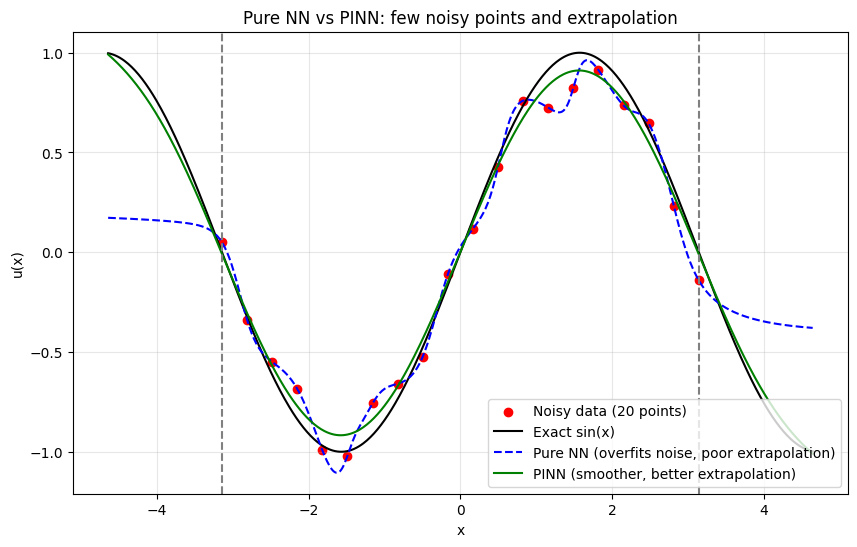

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Noisy data (20 points)
np.random.seed(42)
x_data = np.linspace(-np.pi, np.pi, 20)
y_data = np.sin(x_data) + 0.1 * np.random.randn(20)

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1)
        )
    def forward(self, x):
        return self.net(x)

# Train pure data-driven NN
model_data = SimpleNN()
opt_data = torch.optim.Adam(model_data.parameters(), lr=0.01)
x_torch = torch.tensor(x_data.reshape(-1,1), dtype=torch.float32)
y_torch = torch.tensor(y_data.reshape(-1,1), dtype=torch.float32)

for epoch in range(5000):
    pred = model_data(x_torch)
    loss = nn.MSELoss()(pred, y_torch)
    if epoch % 500 == 0:
        with torch.no_grad():
            print(f"Epoch {epoch}, Data Loss: {loss.item():.4f}")
    opt_data.zero_grad()
    loss.backward()
    opt_data.step()

# Train PINN with physics: enforce u_xx + u ≈ 0
model_pinn = SimpleNN()
opt_pinn = torch.optim.Adam(model_pinn.parameters(), lr=0.01)
# Collocation points are fixed; create once with requires_grad=True
x_colloc = torch.linspace(-np.pi, np.pi, 300).reshape(-1, 1).requires_grad_(True)

for epoch in range(5000):
    # Zero any accumulated gradient on the collocation tensor before each step
    if x_colloc.grad is not None:
        x_colloc.grad.zero_()

    # Data loss
    pred_data = model_pinn(x_torch)
    loss_data = nn.MSELoss()(pred_data, y_torch)

    # Physics loss: enforce u_xx + u = 0 (satisfied by sin(x) and cos(x))
    u = model_pinn(x_colloc)
    u_x = torch.autograd.grad(u, x_colloc, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_colloc, torch.ones_like(u_x), create_graph=True)[0]
    residual = u_xx + u
    loss_phys = torch.mean(residual**2)

    loss = loss_data + 20 * loss_phys
    opt_pinn.zero_grad()
    loss.backward()
    opt_pinn.step()

# Plot with extrapolation
x_test = np.linspace(-np.pi-1.5, np.pi+1.5, 600)
x_test_torch = torch.tensor(x_test.reshape(-1,1), dtype=torch.float32)

with torch.no_grad():
    y_exact = np.sin(x_test)
    y_data_nn = model_data(x_test_torch).numpy().flatten()
    y_pinn = model_pinn(x_test_torch).numpy().flatten()

plt.figure(figsize=(10,6))
plt.scatter(x_data, y_data, color='red', label='Noisy data (20 points)')
plt.plot(x_test, y_exact, 'k-', label='Exact sin(x)')
plt.plot(x_test, y_data_nn, 'b--', label='Pure NN (overfits noise, poor extrapolation)')
plt.plot(x_test, y_pinn, 'g-', label='PINN (smoother, better extrapolation)')
plt.axvline(-np.pi, color='gray', linestyle='--')
plt.axvline(np.pi, color='gray', linestyle='--')
plt.legend()
plt.title('Pure NN vs PINN: few noisy points and extrapolation')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.grid(alpha=0.3)
plt.show()